# Import

In [1]:
%load_ext autoreload
%autoreload 2

# Import required packages
import torch
import numpy as np
import normflows as nf
from torch.utils.data import TensorDataset, DataLoader, random_split

from matplotlib import pyplot as plt

from tqdm import tqdm

import joblib
import sklearn
import datetime

import sys
sys.path.append('../src')
import ice

# PCA

In [2]:
# attenu_pca = sklearn.decomposition.PCA(n_components = 32)

# attenu_fromEm_standard = np.load('attenu_fromEm_standard.npz')['attenu_fromEm_standard']
# attenu_fromEm_standard = torch.tensor(attenu_fromEm_standard)
# attenu_fromEm_dataset = TensorDataset(attenu_fromEm_standard, attenu_fromEm_standard)

# train_size = int(0.7 * len(attenu_fromEm_standard))
# val_size = int((len(attenu_fromEm_standard) - train_size)/2)
# test_size = int(len(attenu_fromEm_standard) - train_size - val_size)

# generator = torch.Generator().manual_seed(42)
# attenu_fromEm_train_dataset, attenu_fromEm_val_dataset, attenu_fromEm_test_dataset = random_split(attenu_fromEm_dataset, [train_size, val_size, test_size], generator=generator)

# torch.save(attenu_fromEm_train_dataset, 'attenu_fromEm_train_dataset.pt')
# torch.save(attenu_fromEm_val_dataset, 'attenu_fromEm_val_dataset.pt')
# torch.save(attenu_fromEm_test_dataset, 'attenu_fromEm_test_dataset.pt')

# attenu_pca.fit(attenu_fromEm_train_dataset[:][0].detach().numpy()[:, 0, :, :].reshape((-1, attenu_fromEm_train_dataset[:][0].shape[2] ** 2)))

# import joblib

# joblib.dump(attenu_pca, f'attenu_pca{datetime.datetime.now()}.pkl') 

In [3]:
# load data: attenuation rate in PCA latent space
num_epochs = 50
batch_size = 4

attenu_pca = sklearn.decomposition.PCA(n_components = 32)
attenu_fromEm_standard = np.load('attenu_fromEm_standard.npz')['attenu_fromEm_standard']
attenu_latent = attenu_pca.fit_transform(attenu_fromEm_standard[:, 0, :, :].reshape((-1, attenu_fromEm_standard.shape[2] ** 2)))
attenu_latent = torch.tensor(attenu_latent).float()

import joblib
joblib.dump(attenu_pca, f'attenu_pca{datetime.datetime.now()}.pkl') 
torch.save(attenu_latent, 'attenu_latent_pca.pt')

# train val test split
attenu_latent_dataset = TensorDataset(attenu_latent, attenu_latent)

train_size = (int(0.7 * len(attenu_latent)) // batch_size) * batch_size
val_size = int((len(attenu_latent) - train_size)/2)
test_size = int(len(attenu_latent) - train_size - val_size)

generator = torch.Generator().manual_seed(42)
attenu_latent_train_dataset, attenu_latent_val_dataset, attenu_latent_test_dataset = random_split(attenu_latent_dataset, [train_size, val_size, test_size], generator=generator)

attenu_latent_train_dataloader = DataLoader(attenu_latent_train_dataset, batch_size = batch_size, shuffle = 1)
attenu_latent_val_dataloader = DataLoader(attenu_latent_val_dataset, batch_size = batch_size, shuffle = 1)
attenu_latent_test_dataloader = DataLoader(attenu_latent_test_dataset, batch_size = batch_size, shuffle = 1)

# Architecture (normflows, real NVP)

In [4]:
# Set up model
in_features = int(attenu_latent.shape[1]/2)

# Define list of flows
num_layers = 32
flows = []
for i in range(num_layers):
    # Neural network with two hidden layers having 64 units each
    # Last layer is initialized by zeros making training more stable
    param_map = nf.nets.MLP([16, 64, 64, 32], init_zeros=True)
    # Add flow layer
    flows.append(nf.flows.AffineCouplingBlock(param_map))
    # Swap dimensions
    flows.append(nf.flows.Permute(32, mode='swap'))


In [5]:
# base distribution is a Gaussian with num of dimension same as training data
base = nf.distributions.base.DiagGaussian(32)

# Construct flow model
model = nf.NormalizingFlow(base, flows)

In [6]:
model

NormalizingFlow(
  (q0): DiagGaussian()
  (flows): ModuleList(
    (0): AffineCouplingBlock(
      (flows): ModuleList(
        (0): Split()
        (1): AffineCoupling(
          (param_map): MLP(
            (net): Sequential(
              (0): Linear(in_features=16, out_features=64, bias=True)
              (1): LeakyReLU(negative_slope=0.0)
              (2): Linear(in_features=64, out_features=64, bias=True)
              (3): LeakyReLU(negative_slope=0.0)
              (4): Linear(in_features=64, out_features=32, bias=True)
            )
          )
        )
        (2): Merge()
      )
    )
    (1): Permute()
    (2): AffineCouplingBlock(
      (flows): ModuleList(
        (0): Split()
        (1): AffineCoupling(
          (param_map): MLP(
            (net): Sequential(
              (0): Linear(in_features=16, out_features=64, bias=True)
              (1): LeakyReLU(negative_slope=0.0)
              (2): Linear(in_features=64, out_features=64, bias=True)
              (3):

# Training

In [7]:
# using linear regression to prevent overfitting
window_size = 100

reg = sklearn.linear_model.LinearRegression()
window = np.arange(window_size).reshape(-1, 1)

# Train model
max_epoch = 5000
early_stopping_threshold = 1e-3

epoch_loss = np.array([])
epoch_loss_val = np.array([])

optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-5)
model.train()

try:
    for epoch in range(max_epoch):
        optimizer.zero_grad()

        start = torch.Event(enable_timing=True)
        end = torch.Event(enable_timing=True)
        start.record()

        running_loss = 0.0
        running_loss_val = 0.0

        for train_batch, _ in attenu_latent_train_dataloader:
            # Compute loss
            loss = model.forward_kld(train_batch)

            # Do backprop and optimizer step
            if ~(torch.isnan(loss) | torch.isinf(loss)):
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * train_batch.size(0)

        for val_batch, _ in attenu_latent_val_dataloader:
            # Compute loss
            val_loss = model.forward_kld(val_batch)

            # Do backprop and optimizer step
            if ~(torch.isnan(val_loss) | torch.isinf(val_loss)):
                val_loss.backward()
                optimizer.step()
                running_loss_val += val_loss.item() * val_batch.size(0)
        
        #print(running_loss)

        epoch_loss = np.append(epoch_loss, running_loss / len(attenu_latent_train_dataloader.dataset))
        epoch_loss_val = np.append(epoch_loss_val, running_loss / len(attenu_latent_train_dataloader.dataset))

        if epoch >= window.shape[0]:
            #print(epoch_loss[-window_size:])
            #print(epoch_loss_val[-window_size:])
            reg.fit(window, epoch_loss[-window_size:])
            epoch_loss_slope = reg.coef_
            print(f"Epoch loss slope: {epoch_loss_slope}")

            reg.fit(window, epoch_loss_val[-window_size:])
            epoch_loss_val_slope = reg.coef_
            print(f"Epoch validation loss slope: {epoch_loss_val_slope}")

            if (np.abs(epoch_loss_slope) < early_stopping_threshold) or (np.abs(epoch_loss_val_slope) < early_stopping_threshold):
                print("Early stopping")
                break

        end.record()

        print(f"Epoch [{epoch + 1}/{max_epoch}], loss: {epoch_loss[epoch]:.4f}, validation loss: {epoch_loss_val[epoch]:.4f}, time elapsed = {start.elapsed_time(end)/1000:.2f} s")

    torch.save(model.state_dict(), f'realNVP_{datetime.datetime.now()}.pth')
    np.savez(f'realNVP_{datetime.datetime.now()}_loss.npz',epoch_loss = epoch_loss, epoch_loss_val = epoch_loss_val) 

except KeyboardInterrupt:
    torch.save(model.state_dict(), f'realNVP_{datetime.datetime.now()}.pth')
    np.savez(f'realNVP_{datetime.datetime.now()}_loss.npz',epoch_loss = epoch_loss, epoch_loss_val = epoch_loss_val)


Epoch [1/5000], loss: 177.9247, validation loss: 177.9247, time elapsed = 0.26 s
Epoch [2/5000], loss: 152.6068, validation loss: 152.6068, time elapsed = 0.27 s
Epoch [3/5000], loss: 137.3593, validation loss: 137.3593, time elapsed = 0.26 s
Epoch [4/5000], loss: 122.7332, validation loss: 122.7332, time elapsed = 0.25 s
Epoch [5/5000], loss: 110.6521, validation loss: 110.6521, time elapsed = 0.26 s
Epoch [6/5000], loss: 102.3209, validation loss: 102.3209, time elapsed = 0.27 s
Epoch [7/5000], loss: 95.4981, validation loss: 95.4981, time elapsed = 0.31 s
Epoch [8/5000], loss: 90.4969, validation loss: 90.4969, time elapsed = 0.28 s
Epoch [9/5000], loss: 86.6748, validation loss: 86.6748, time elapsed = 0.28 s
Epoch [10/5000], loss: 83.1512, validation loss: 83.1512, time elapsed = 0.26 s
Epoch [11/5000], loss: 80.4390, validation loss: 80.4390, time elapsed = 0.26 s
Epoch [12/5000], loss: 78.4059, validation loss: 78.4059, time elapsed = 0.26 s
Epoch [13/5000], loss: 76.4120, valid

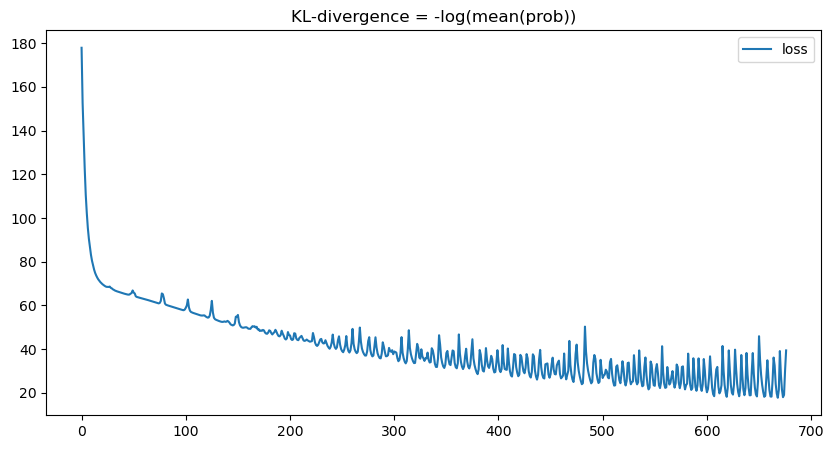

In [8]:
# Plot loss
#epoch_loss = np.load('../testing/realNVP_2026-06-22 15:29:54.090759_loss.npz')['epoch_loss']
#epoch_loss_val = np.load('../testing/realNVP_2026-06-22 15:29:54.090759_loss.npz')['epoch_loss_val']

plt.figure(figsize=(10, 5))
plt.plot(epoch_loss_val[0:-1], label='loss')
plt.title('KL-divergence = -log(mean(prob))')
plt.legend()
plt.show()


# Sampling

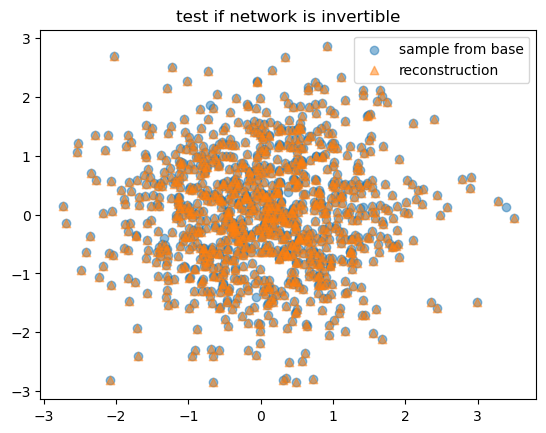

In [14]:
x0 = base.sample(1000)
x1_from_x0 = model.forward(x0)
x1 = model.sample(1000)[0]
x0_from_x1_from_x0 = model.inverse(x1_from_x0)

x0 = x0.detach().numpy()
x1 = x1.detach().numpy()
x1_from_x0 = x1_from_x0.detach().numpy()
x0_from_x1_from_x0 = x0_from_x1_from_x0.detach().numpy()

plt.scatter(x0[:, 0], x0[:, 1], alpha = 0.5, label = 'sample from base')
#plt.scatter(x1[:, 0], x1[:, 1])
#plt.scatter(x1_from_x0[:, 0], x1_from_x0[:, 1])
plt.scatter(x0_from_x1_from_x0[:, 0], x0_from_x1_from_x0[:, 1], alpha = 0.5, label = 'reconstruction', marker = '^')
plt.title("test if network is invertible")
plt.legend()

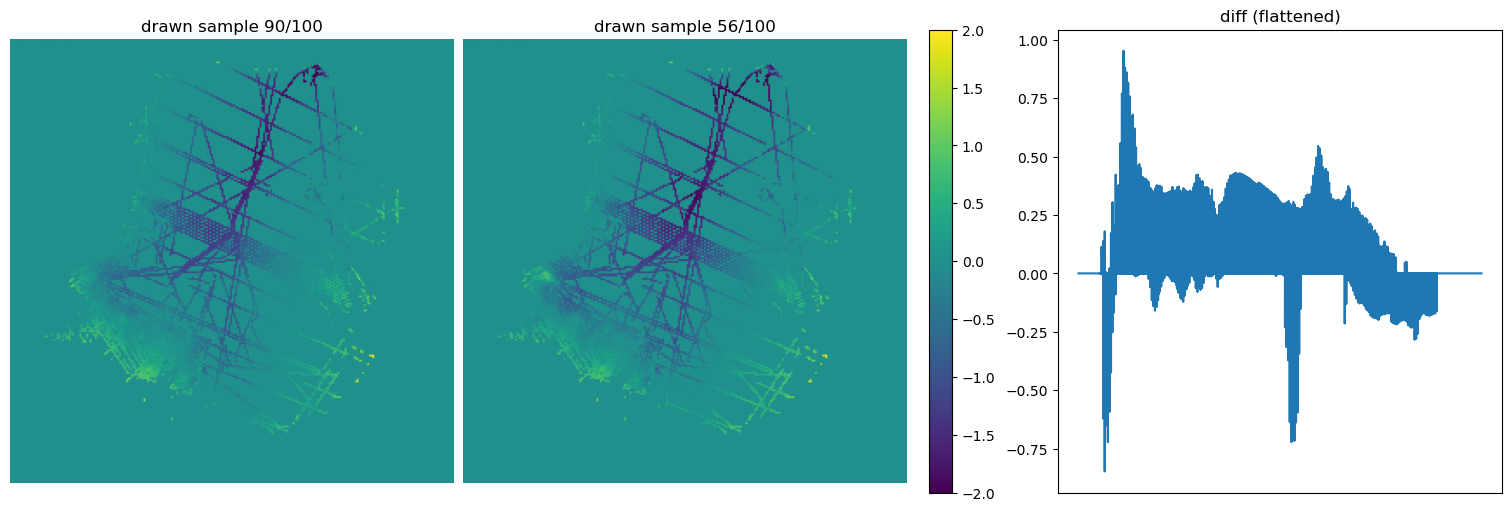

In [15]:
#attenu_pca = joblib.load('../testing/attenu_pca2026-06-12 15:13:52.857122.pkl')

attenu_samples_latent, attenu_samples_log_prob = model.sample(100)
attenu_samples = attenu_pca.inverse_transform(attenu_samples_latent.detach().numpy())
attenu_samples = attenu_samples.reshape((attenu_samples.shape[0], 256, 256))

figs, axs = plt.subplots(1,3, figsize = (15, 5), layout="constrained")

vmin = -2
vmax = 2

rng = np.random.default_rng()
idx = rng.choice(attenu_samples.shape[0], size=2, replace=False)

axs[0].imshow(attenu_samples[idx[0], :, :], vmin = vmin, vmax = vmax)
axs[0].set_title(f"drawn sample {idx[0]}/{attenu_samples.shape[0]}")
axs[0].set_axis_off()

im1 = axs[1].imshow(attenu_samples[idx[1], :, :], vmin = vmin, vmax = vmax)
axs[1].set_title(f"drawn sample {idx[1]}/{attenu_samples.shape[0]}")
axs[1].set_axis_off()
plt.colorbar(im1)

axs[2].plot((attenu_samples[idx[0], :, :] - attenu_samples[idx[1], :, :]).flatten())
axs[2].set_title("diff (flattened)")
axs[2].xaxis.set_visible(False)

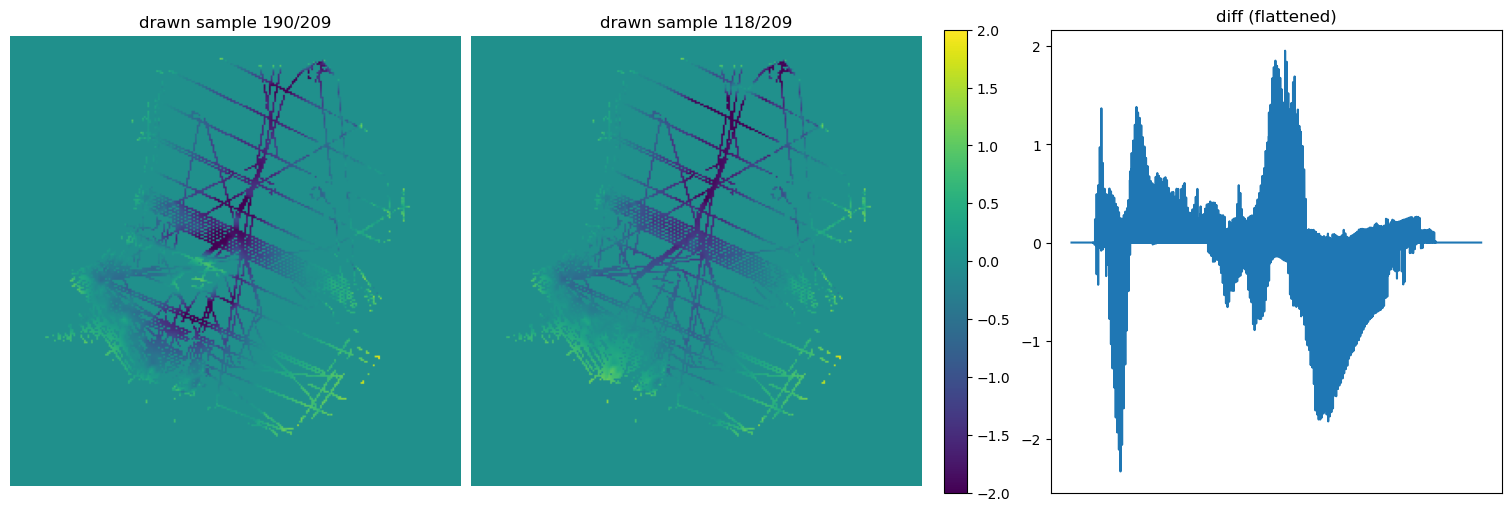

In [16]:
# compare variance to ensemble samples

attenu_ensemble_samples = attenu_pca.inverse_transform(attenu_latent.detach().numpy())
attenu_ensemble_samples = attenu_ensemble_samples.reshape((attenu_ensemble_samples.shape[0], 256, 256))
figs, axs = plt.subplots(1,3, figsize = (15, 5), layout="constrained")

vmin = -2
vmax = 2

rng = np.random.default_rng()
idx = rng.choice(attenu_ensemble_samples.shape[0], size=2, replace=False)

axs[0].imshow(attenu_ensemble_samples[idx[0], :, :], vmin = vmin, vmax = vmax)
axs[0].set_title(f"drawn sample {idx[0]}/{attenu_ensemble_samples.shape[0]}")
axs[0].set_axis_off()

im1 = axs[1].imshow(attenu_ensemble_samples[idx[1], :, :], vmin = vmin, vmax = vmax)
axs[1].set_title(f"drawn sample {idx[1]}/{attenu_ensemble_samples.shape[0]}")
axs[1].set_axis_off()
plt.colorbar(im1)

axs[2].plot((attenu_ensemble_samples[idx[0], :, :] - attenu_ensemble_samples[idx[1], :, :]).flatten())
axs[2].set_title("diff (flattened)")
axs[2].xaxis.set_visible(False)

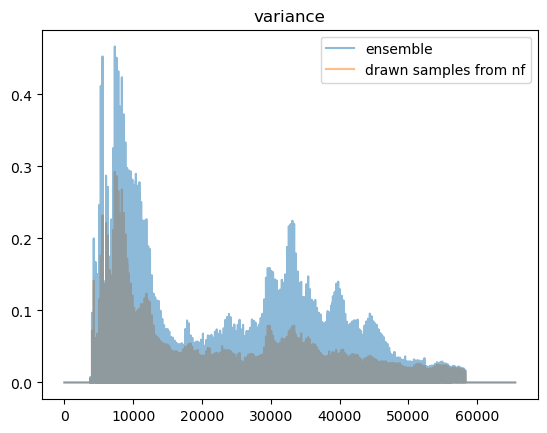

In [17]:
var_attenu_ensemble_samples = np.var(attenu_ensemble_samples, axis = 0)
var_attenu_samples = np.var(attenu_samples, axis = 0)

plt.plot(var_attenu_ensemble_samples.flatten(), label = 'ensemble', alpha = 0.5, zorder = 5)
plt.plot(var_attenu_samples.flatten(), label = 'drawn samples from nf', alpha = 0.5)
plt.title("variance")
plt.legend()

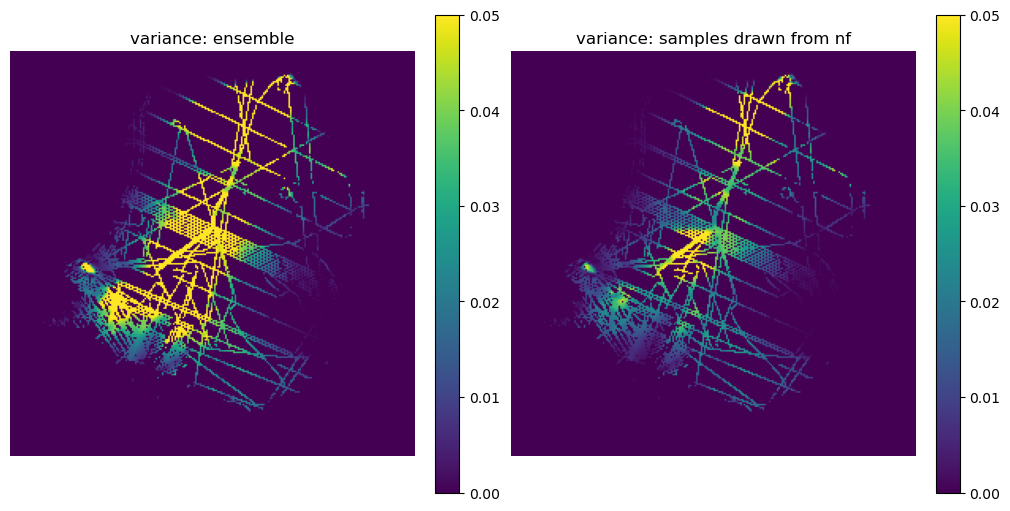

In [18]:
figs, axs = plt.subplots(1,2, figsize = (10, 5), layout="constrained")

vmin = 0
vmax = 0.05

im0 = axs[0].imshow(var_attenu_ensemble_samples, vmin = vmin, vmax = vmax)
axs[0].set_title(f"variance: ensemble")
axs[0].set_axis_off()
plt.colorbar(im0)

im1 = axs[1].imshow(var_attenu_samples, vmin = vmin, vmax = vmax)
axs[1].set_title(f"variance: samples drawn from nf")
axs[1].set_axis_off()
plt.colorbar(im1)